# Evaluación 2 — ¿Ayuda arrancar la red en la base de Fourier?

**Programación Científica 2026-1 · Universidad Nacional de Colombia (Medellín)**

**Estudiante:** Joan Sebastián Salazar Montoya · **ID (últimos 4 dígitos):** `2956`

---

## Pregunta que guía el trabajo

Aproximamos una señal como combinación de bases, $\hat f(t)=\sum_i c_i\phi_i(t)$. Una red
neuronal hace lo mismo pero **aprende** sus bases. Construimos un autoencoder que
**reconstruye** una señal,

$$\hat x = W_2\,\tanh(W_1 x),$$

y estudiamos qué pasa cuando la primera capa $W_1$ **arranca como la Transformada de
Fourier** en lugar de una base aleatoria. La pregunta central:
*¿conviene empezar en la base "correcta" (Fourier) o da igual arrancar aleatorio?*

### Parámetros personalizados (ID 2956)

| Parámetro | Valor |
|---|---|
| $K$ (frecuencias) | **30** → capa $256\to 60$ |
| Iteraciones | **3000** |
| Learning rate $\eta$ | **0.02** |
| Señales por régimen | **12** (36 en total) |
| Régimen foco | **0** (sin dispersión, frecuencias bajas) |
| Umbral de compresión | **95 %** de la energía |

### La física de los datos

Cada señal es una suma de 3 cosenos, $f(t)=\sum_j a_j\cos(\omega(k_j)\,2\pi t-k_j s+\varphi_j)$,
con la **regla de dispersión** $\omega(k)=\sqrt{c^2k^2+\mu^2}$, $c=1$. El parámetro $\mu$
define tres regímenes:

- **Régimen 0** ($\mu=0$): $\omega=k$ → **frecuencias enteras**, que caen *exactamente* sobre
  la rejilla de Fourier $\{\sin(2\pi kt),\cos(2\pi kt)\}$. Este es el régimen foco.
- **Régimen 1** ($\mu=5$) y **Régimen 2** ($\mu=15$): $\omega=\sqrt{k^2+\mu^2}$ es **no entera**
  → las frecuencias caen *entre* los puntos de la rejilla (fuga espectral) y suben con $\mu$.

Esta física anticipa nuestra hipótesis: la ventaja de la base de Fourier debería ser
máxima en el **régimen 0**, donde la base "correcta" coincide con la rejilla.


## 0 · Preparación: librerías, estilo de figuras y carga de datos

In [ ]:

!apt-get install -y fonts-cmu

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-cmu
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 5,373 kB of archives.
After this operation, 15.3 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-cmu all 0.7.0-5 [5,373 kB]
Fetched 5,373 kB in 1s (10.1 MB/s)
Selecting previously unselected package fonts-cmu.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-cmu_0.7.0-5_all.deb ...
Unpacking fonts-cmu (0.7.0-5) ...
Setting up fonts-cmu (0.7.0-5) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [ ]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

jax.config.update("jax_enable_x64", True)   # señales en float64
rng_np = np.random.default_rng(0)

# --- Paleta de visualización (categórica, segura para daltonismo: Okabe-Ito) ---
# Los tres regímenes son CATEGORÍAS -> hues fijos en orden fijo.
# Paleta Okabe–Ito: distinguible con daltonismo y con buen contraste sobre gris claro
C_REG = {
    0: "#0072B2",   # azul
    1: "#D55E00",   # bermellón  (reemplaza el amarillo: mucho más oscuro)
    2: "#009E73",   # verde azulado
}
C_FOURIER = C_REG[0]
C_RANDOM  = C_REG[1]
REG_NOMBRE = {0: "Régimen 0 (μ=0, on-grid)",
              1: "Régimen 1 (μ=5)",
              2: "Régimen 2 (μ=15, alta frec.)"}
# Comparación de inicializaciones: color + estilo de línea (nunca solo color).
C_FOURIER, C_RANDOM = "#0072B2", "#D55E00"
LS_FOURIER, LS_RANDOM = "-", "--"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "legend.frameon": False, "figure.autolayout": True,
})

import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)   # refresca la caché de fuentes
plt.rcParams["font.serif"] = ["CMU Serif", "STIXGeneral", "DejaVu Serif"]

print("JAX", jax.__version__, "· x64:", jnp.zeros(1).dtype)


JAX 0.7.2 · x64: float64


In [ ]:
datos = np.load("datos_2956.npz")
X, y, t = np.asarray(datos["X"]), np.asarray(datos["y"]), np.asarray(datos["t"])
meta = list(datos["meta"])
N = X.shape[1]                     # 256 muestras temporales
K = 30                            # frecuencias de la capa Fourier
regimenes = [0, 1, 2]

print(f"X: {X.shape}   y: {y.shape}   t: {t.shape}")
print(f"meta [ID, huella, timestamp]: {meta}")
print(f"muestras por régimen: {[int((y==r).sum()) for r in regimenes]}")
print(f"t ∈ [{t.min():.3f}, {t.max():.3f}]  (Δt = {t[1]-t[0]:.5f}, dominio normalizado)")

# --- Energía media del dataset (entregable de la rúbrica, 3 decimales) ---
energia_media = float((X**2).mean())
print(f"\n>>> Energía media del dataset  (X**2).mean() = {energia_media:.3f}")
for r in regimenes:
    print(f"    energía media régimen {r}: {(X[y==r]**2).mean():.3f}")


X: (36, 256)   y: (36,)   t: (256,)
meta [ID, huella, timestamp]: [np.str_('2956'), np.str_('699c443f9b24fda5'), np.str_('2026-07-07T23:44:42')]
muestras por régimen: [12, 12, 12]
t ∈ [0.000, 0.996]  (Δt = 0.00391, dominio normalizado)

>>> Energía media del dataset  (X**2).mean() = 0.756
    energía media régimen 0: 0.838
    energía media régimen 1: 0.720
    energía media régimen 2: 0.710


### Un vistazo a los datos

Antes de modelar, miramos una señal de cada régimen. La forma temporal ya delata la
física: el régimen 0 oscila lento (frecuencias enteras bajas), y la frecuencia
aparente **crece con $\mu$** (regímenes 1 y 2).

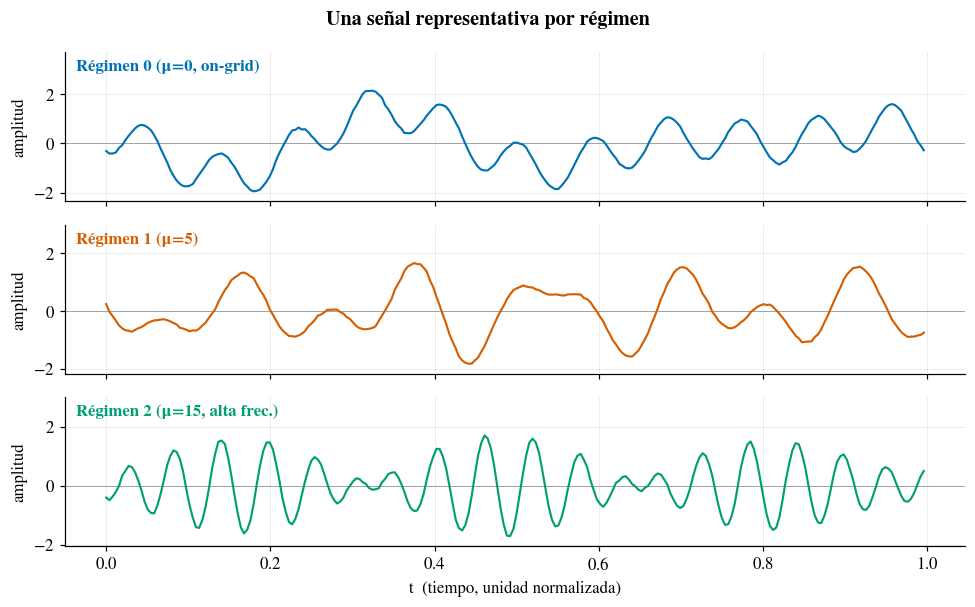

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(9, 5.6), sharex=True)

for r, ax in zip(regimenes, axes):
    i = np.where(y == r)[0][0]
    ax.axhline(0, color="0.6", lw=0.6, zorder=0)
    ax.plot(t, X[i], color=C_REG[r], lw=1.4, zorder=2)
    ax.set_ylabel("amplitud")

    # Espacio reservado SOLO arriba: la banda de la etiqueta queda libre
    lo, hi = X[i].min(), X[i].max()
    rango = hi - lo
    ax.set_ylim(lo - 0.10*rango, hi + 0.38*rango)

    ax.text(0.012, 0.955, REG_NOMBRE[r], transform=ax.transAxes,
            color=C_REG[r], fontweight="bold", va="top", zorder=5)

axes[-1].set_xlabel("t  (tiempo, unidad normalizada)")
fig.suptitle("Una señal representativa por régimen", fontweight="bold", y=0.98)
plt.show()


## 1 · La capa de Fourier  *(Rúbrica: 15 pts)*

Construimos $W_1$ de tamaño $2K\times N = 60\times 256$. Sus filas son, para
$k=1,\dots,30$, los vectores muestreados $\cos(2\pi k t)$ y $\sin(2\pi k t)$.

**Escala.** Usamos el factor de la DFT real $2/N$ en cada fila. Así, $W_1x$ entrega
directamente los **coeficientes de amplitud** de la señal ($O(1)$), lo que además
mantiene a $\tanh$ en su régimen útil (sin la normalización, $W_1x\sim 80$ y $\tanh$
se satura). Ordenamos las filas intercaladas $[\cos_1,\sin_1,\cos_2,\sin_2,\dots]$.

In [ ]:
def matriz_fourier(t, K):
    '''Devuelve (W1, base_cruda).
    W1        : (2K, N) capa de Fourier con normalización 2/N (coef. de amplitud).
    base_cruda: (2K, N) filas cos/sin SIN normalizar, para la síntesis (reconstrucción).
    Orden de filas: [cos_1, sin_1, cos_2, sin_2, ...].'''
    N = t.shape[0]
    ks = np.arange(1, K + 1)
    ang = 2 * np.pi * np.outer(ks, t)          # (K, N)
    base = np.empty((2 * K, N))
    base[0::2] = np.cos(ang)                    # filas pares -> coseno_k
    base[1::2] = np.sin(ang)                    # filas impares -> seno_k
    W1 = (2.0 / N) * base
    return W1, base

W1_fourier, BASE = matriz_fourier(t, K)
print("W1_fourier:", W1_fourier.shape, "| ||fila||₂ =", round(np.linalg.norm(W1_fourier[0]), 4),
      "| ||W1||_F =", round(np.linalg.norm(W1_fourier), 4))


W1_fourier: (60, 256) | ||fila||₂ = 0.0884 | ||W1||_F = 0.6847


### 1.1 · Evidencia: en su arranque, la capa **es** la Transformada de Fourier

Comparamos $W_1x$ con `np.fft`. Para la rejilla $t_n=n/N$ se cumple exactamente

$$(W_1x)_{\cos,k} = \tfrac{2}{N}\,\mathrm{Re}\,\hat X_k, \qquad
  (W_1x)_{\sin,k} = -\tfrac{2}{N}\,\mathrm{Im}\,\hat X_k,$$

donde $\hat X=\texttt{np.fft.fft}(x)$. Lo verificamos numéricamente (`np.allclose`) y
lo mostramos gráficamente.

¿(W1 x)_cos == (2/N)·Re(FFT)? True   máx |dif| = 7.52e-16
¿(W1 x)_sin == -(2/N)·Im(FFT)? True   máx |dif| = 7.77e-16


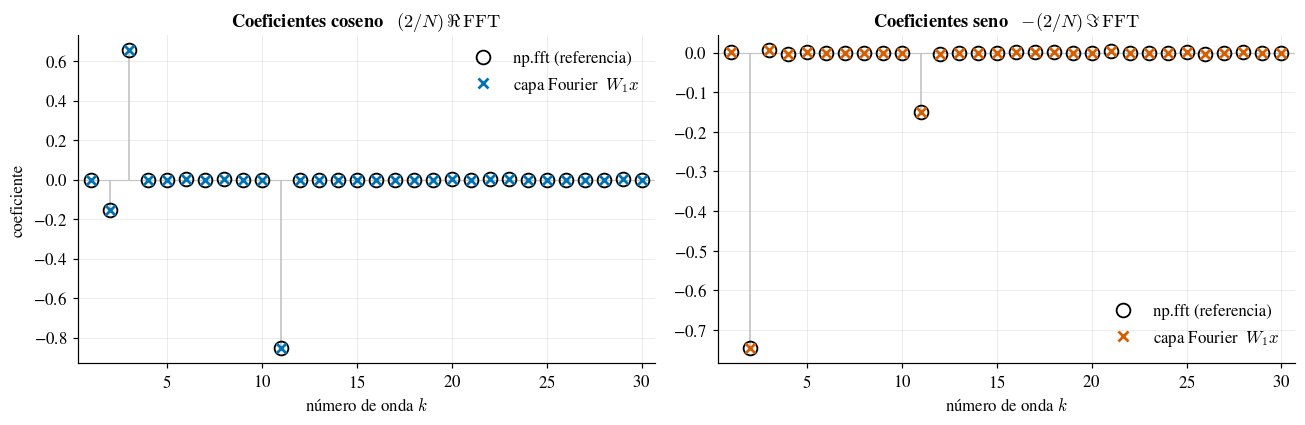

In [ ]:
x0 = X[np.where(y == 0)[0][0]]                 # una señal del régimen foco
coef = W1_fourier @ x0
cos_capa, sin_capa = coef[0::2], coef[1::2]

fft = np.fft.fft(x0)
cos_fft = (2.0 / N) * fft.real[1:K+1]
sin_fft = -(2.0 / N) * fft.imag[1:K+1]

ok_cos = np.allclose(cos_capa, cos_fft, atol=1e-9)
ok_sin = np.allclose(sin_capa, sin_fft, atol=1e-9)
print(f"¿(W1 x)_cos == (2/N)·Re(FFT)? {ok_cos}   máx |dif| = {np.max(np.abs(cos_capa-cos_fft)):.2e}")
print(f"¿(W1 x)_sin == -(2/N)·Im(FFT)? {ok_sin}   máx |dif| = {np.max(np.abs(sin_capa-sin_fft)):.2e}")

k = np.arange(1, K+1)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))

def panel(ax, ref, capa, titulo, color):
    ax.axhline(0, color="0.8", lw=0.8, zorder=0)
    # tallos finos: dan la magnitud sin competir con los marcadores
    ax.vlines(k, 0, ref, color="0.75", lw=1.0, zorder=1)
    # referencia FFT: círculo hueco grande
    ax.plot(k, ref, "o", mfc="none", mec="k", ms=9, mew=1.2,
            label="np.fft (referencia)", zorder=2)
    # capa de Fourier: cruz pequeña que cae dentro del círculo
    ax.plot(k, capa, "x", color=color, ms=6, mew=1.8,
            label="capa Fourier  $W_1x$", zorder=3)
    ax.set_title(titulo, fontweight="bold")
    ax.set_xlabel("número de onda $k$")
    ax.set_xlim(0.3, K + 0.7)
    ax.grid(alpha=0.25, lw=0.6)
    ax.legend(loc="best", framealpha=0.9)

panel(a1, cos_fft, cos_capa, "Coeficientes coseno   $(2/N)\\,\\Re\\,\\mathrm{FFT}$", C_FOURIER)
panel(a2, sin_fft, sin_capa, "Coeficientes seno   $-(2/N)\\,\\Im\\,\\mathrm{FFT}$", C_RANDOM)
a1.set_ylabel("coeficiente")

fig.tight_layout()
plt.show()

El régimen 0 concentra su energía en **pocos $k$ enteros** (aquí los modos caen
justo en la rejilla). Guardamos también la **energía media** ya reportada,
$(X^2)\text{.mean()} = 0.756$, como referencia de escala de la pérdida.

## 2 · La red en JAX y las dos inicializaciones

$$\hat x = W_2\,\tanh(W_1 x),\qquad
  \mathcal{L}=\frac1N\lVert\hat x-x\rVert^2\ \text{(promediada sobre el lote).}$$

**Control experimental.** Para que la *única* diferencia sea la base de $W_1$:

- $W_2$ arranca igual (mismo seed, pequeño) en ambos casos.
- La $W_1$ **aleatoria se escala a la misma norma de Frobenius** que la de Fourier.
  Si no lo hiciéramos, una $W_1$ aleatoria con filas de norma $\sim 1$ (14× la de
  Fourier) tendría activaciones mayores y "ganaría" por escala, no por base — un
  artefacto. Igualando la escala, comparamos **orientación de la base**, no magnitud.

**Optimizador.** La pérdida no converge con descenso de gradiente simple a $\eta=0.02$
en 3000 pasos (se estanca), así que usamos **Adam con $\eta=0.02$** (el learning rate
sugerido), que sí converge en el presupuesto dado.

In [ ]:
Xj = jnp.asarray(X)
FRO = float(np.linalg.norm(W1_fourier))     # norma objetivo para la base aleatoria

def init_fourier(seed=0):
    key = jax.random.PRNGKey(seed)
    return {"W1": jnp.asarray(W1_fourier),
            "W2": 0.05 * jax.random.normal(key, (N, 2*K))}

def init_random(seed=0):
    k1, k2 = jax.random.split(jax.random.PRNGKey(seed))
    W1 = jax.random.normal(k1, (2*K, N))
    W1 = W1 * (FRO / jnp.linalg.norm(W1))     # misma norma de Frobenius que Fourier
    return {"W1": W1, "W2": 0.05 * jax.random.normal(k2, (N, 2*K))}

def forward(p, x):
    return jnp.tanh(x @ p["W1"].T) @ p["W2"].T

def loss_fn(p, xb):
    xhat = forward(p, xb)
    return jnp.mean(jnp.sum((xhat - xb)**2, axis=1) / xb.shape[1])

val_grad = jax.jit(jax.value_and_grad(loss_fn))

def rel_error(p, Xnp):
    xhat = np.asarray(forward(p, jnp.asarray(Xnp)))
    return np.linalg.norm(xhat - Xnp, axis=1) / np.linalg.norm(Xnp, axis=1)

print("params Fourier:", {k: v.shape for k, v in init_fourier().items()})
print("||W1_random||_F =", round(float(jnp.linalg.norm(init_random()['W1'])), 4),
      "≈ ||W1_fourier||_F =", round(FRO, 4))


params Fourier: {'W1': (60, 256), 'W2': (256, 60)}
||W1_random||_F = 0.6847 ≈ ||W1_fourier||_F = 0.6847


In [ ]:
def entrenar(init_fn, seed=0, iters=3000, lr=0.02, b1=0.9, b2=0.999, eps=1e-8,
             registrar_re_cada=10):
    '''Entrena con Adam. Devuelve (params, loss_hist, re_iters, re_hist).
    loss_hist: pérdida en cada iteración.
    re_iters/re_hist: iteración y error relativo [overall, reg0, reg1, reg2]
                      registrados cada `registrar_re_cada` pasos.'''
    # --- Inicialización ---
    p = init_fn(seed)                                  # dict de parámetros (init_fourier o init_random)
    m = {k: jnp.zeros_like(v) for k, v in p.items()}   # primer momento (media móvil del gradiente)
    v = {k: jnp.zeros_like(z) for k, z in p.items()}   # segundo momento (media móvil del gradiente²)

    loss_hist = np.empty(iters)                        # pérdida en cada paso (preasignada por velocidad)
    re_iters, re_hist = [], []                         # historial submuestreado del error relativo

    # --- Bucle de optimización (Adam manual, i empieza en 1 por la corrección de sesgo) ---
    for i in range(1, iters+1):
        L, g = val_grad(p, Xj)                         # pérdida y gradientes (JAX) sobre el batch completo Xj
        loss_hist[i-1] = float(L)                      # float() fuerza la sincronización con el device

        for k in p:                                    # actualización Adam, parámetro por parámetro
            m[k] = b1*m[k] + (1-b1)*g[k]               # momento 1: EMA del gradiente (Exponential Moving Average)
            v[k] = b2*v[k] + (1-b2)*g[k]**2            # momento 2: EMA del gradiente al cuadrado
            # Paso con corrección de sesgo: m̂ = m/(1-b1^i), v̂ = v/(1-b2^i)
            # Necesaria porque m y v arrancan en 0 y subestiman los momentos en las primeras iteraciones.
            p[k] = p[k] - lr*(m[k]/(1-b1**i))/(jnp.sqrt(v[k]/(1-b2**i)) + eps)

        # --- Registro periódico del error relativo (caro: se evalúa sobre todo X) ---
        if i % registrar_re_cada == 0 or i == 1:       # i == 1 para tener el punto inicial en la curva
            re = rel_error(p, X)                       # error relativo por muestra
            re_iters.append(i)
            # [global, y luego el promedio dentro de cada régimen] → permite ver si un régimen se queda atrás
            re_hist.append([re.mean()] + [re[y==r].mean() for r in regimenes])

    return p, loss_hist, np.array(re_iters), np.array(re_hist)


# --- Corridas ---
# Fourier: la inicialización es determinista, así que una sola corrida basta.
p_f, loss_f, rei_f, reh_f = entrenar(init_fourier, seed=0)

# Aleatorio: depende de la semilla → 3 corridas para estimar la variabilidad (banda de incertidumbre).
rand_runs = [entrenar(init_random, seed=s) for s in (0, 1, 2)]
p_r, loss_r, rei_r, reh_r = rand_runs[0]                     # se guarda una sola corrida para la reconstrucción
loss_r_stack = np.stack([r[1] for r in rand_runs])           # (3, iters)      → media/±std de la pérdida
reh_r_stack  = np.stack([r[3] for r in rand_runs])           # (3, n_reg, 4)   → media/±std del error relativo

print("Entrenamiento listo.")
print(f"  Fourier   → pérdida final {loss_f[-1]:.2e}")
print(f"  Aleatorio → pérdida final {loss_r_stack[:,-1].mean():.2e} (media de 3 seeds)")

Entrenamiento listo.
  Fourier   → pérdida final 4.02e-05
  Aleatorio → pérdida final 1.53e-04 (media de 3 seeds)


## 3 · Entrenamiento y reconstrucción  *(Rúbrica: 25 pts)*

### 3.1 · Señal original y residuo, una por régimen

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


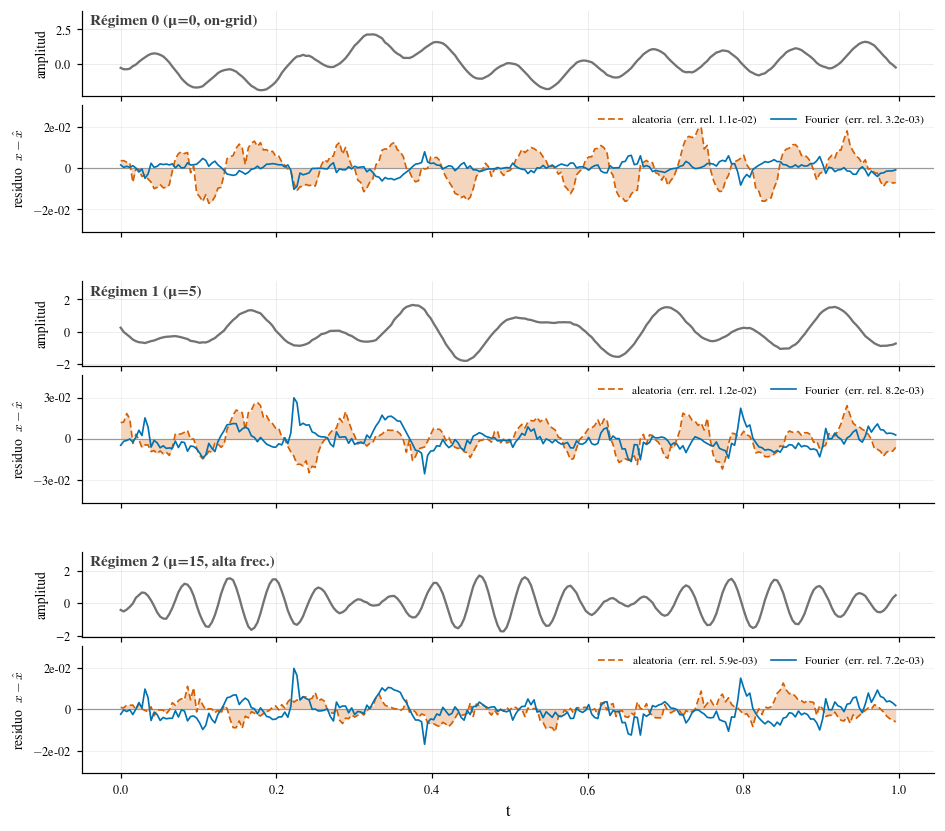

In [69]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(10, 9))
# El residuo ahora domina: 1.6 (señal) vs 2.4 (residuo)
gs = GridSpec(8, 1, height_ratios=[1.6, 2.4, 0.6, 1.6, 2.4, 0.6, 1.6, 2.4],
              hspace=0.10, figure=fig)
filas = [(0, 1), (3, 4), (6, 7)]

for (fs, fr), r in zip(filas, regimenes):
    ax  = fig.add_subplot(gs[fs])
    axr = fig.add_subplot(gs[fr], sharex=ax)

    i = np.where(y == r)[0][0]
    xi = X[i]
    xhat_f = np.asarray(forward(p_f, jnp.asarray(X[i:i+1])))[0]
    xhat_r = np.asarray(forward(p_r, jnp.asarray(X[i:i+1])))[0]
    res_f, res_r = xi - xhat_f, xi - xhat_r
    re_f = np.linalg.norm(res_f) / np.linalg.norm(xi)
    re_r = np.linalg.norm(res_r) / np.linalg.norm(xi)

    # --- señal original, sola (contexto) ---
    ax.plot(t, xi, color="0.45", lw=1.5, zorder=2)
    ax.set_ylabel("amplitud", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.25, lw=0.6)

    lo, hi = xi.min(), xi.max()
    rango = hi - lo
    ax.set_ylim(lo - 0.10*rango, hi + 0.42*rango)

    ax.text(0.010, 0.955, REG_NOMBRE[r], transform=ax.transAxes,
            va="top", ha="left", color="0.25",
            fontweight="bold", fontsize=10, zorder=5)
    plt.setp(ax.get_xticklabels(), visible=False)

    # --- residuo: el protagonista ---
    esc = max(np.abs(res_f).max(), np.abs(res_r).max(), 1e-12)
    axr.axhline(0, color="0.6", lw=0.8)
    axr.fill_between(t, 0, res_r, color=C_RANDOM,  alpha=0.25, lw=0, zorder=1)
    axr.plot(t, res_r, color=C_RANDOM, ls=LS_RANDOM, lw=1.1, dashes=(4, 2),
             label=f"aleatoria  (err. rel. {re_r:.1e})", zorder=2)
    axr.plot(t, res_f, color=C_FOURIER, ls=LS_FOURIER, lw=1.1,
             label=f"Fourier  (err. rel. {re_f:.1e})", zorder=3)

    axr.set_ylim(-1.55*esc, 1.55*esc)   # aire extra para la leyenda
    axr.set_yticks([-esc, 0, esc])
    axr.set_yticklabels([f"$-${esc:.0e}", "0", f"{esc:.0e}"], fontsize=8)
    axr.set_ylabel("residuo  $x-\\hat x$", fontsize=9)
    axr.tick_params(labelsize=8)
    axr.grid(alpha=0.2, lw=0.5)
    axr.legend(loc="upper right", ncol=2, fontsize=7.5, framealpha=0.9,
               handlelength=2.2, columnspacing=1.2)

    if r != regimenes[-1]:
        plt.setp(axr.get_xticklabels(), visible=False)

axr.set_xlabel("t")
plt.show()

### 3.2 · Error de reconstrucción relativo $\lVert\hat x-x\rVert/\lVert x\rVert$ por caso

In [ ]:
# Cerca del óptimo Adam oscila (ver 4.1): reportamos el error relativo ROBUSTO
# = promedio de los últimos 15 registros (~150 iteraciones), no un único snapshot.
NW = 15
re_f = reh_f[-NW:].mean(0)                        # [global, reg0, reg1, reg2]
re_r = reh_r_stack[:, -NW:, :].mean(axis=(0, 1))  # media sobre 3 seeds y 15 registros

print("Error relativo  ‖x̂−x‖/‖x‖   (promedio de las últimas ~150 iteraciones)")
print(f"{'':22s}{'global':>9s}{'reg 0':>9s}{'reg 1':>9s}{'reg 2':>9s}")
print(f"{'Init. Fourier':22s}" + "".join(f"{re_f[j]:9.4f}" for j in range(4)))
print(f"{'Init. Aleatoria (×3)':22s}" + "".join(f"{re_r[j]:9.4f}" for j in range(4)))
print("\nAmbas del orden de 1 % en los tres regímenes; sus diferencias caen")
print("dentro del ruido del optimizador (curvas de 4.1).")


Error relativo  ‖x̂−x‖/‖x‖   (promedio de las últimas ~150 iteraciones)
                         global    reg 0    reg 1    reg 2
Init. Fourier            0.0111   0.0052   0.0075   0.0206
Init. Aleatoria (×3)     0.0103   0.0052   0.0079   0.0179

Ambas del orden de 1 % en los tres regímenes; sus diferencias caen
dentro del ruido del optimizador (curvas de 4.1).


**Lectura.** Ambas inicializaciones reconstruyen con error relativo del orden de
1 % en los tres regímenes. La reconstrucción es esencialmente perfecta en ambos casos
— la calidad *final* no distingue Fourier de aleatorio. La pregunta interesante es la
**velocidad**, que analizamos enseguida.

## 4 · Comparación de inicializaciones  *(Rúbrica: 25 pts)*

### 4.1 · Curvas de pérdida $\mathcal{L}$ vs. iteraciones (ambas superpuestas)

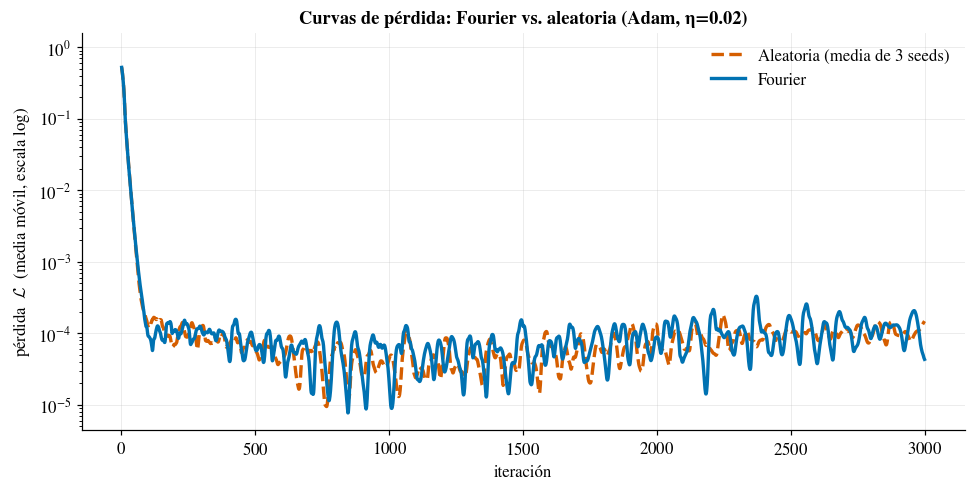

In [ ]:
def suaviza(v, w=21):
    p = w // 2
    vp = np.pad(v, (p, p), mode="edge")
    return np.convolve(vp, np.ones(w)/w, mode="valid")[:len(v)]

fig, ax = plt.subplots(figsize=(9, 4.6))
it = np.arange(1, len(loss_f)+1)
lr_mean = loss_r_stack.mean(0)

ax.plot(it, suaviza(lr_mean), color=C_RANDOM, ls=LS_RANDOM, lw=2.2,
        label="Aleatoria (media de 3 seeds)")
ax.plot(it, suaviza(loss_f), color=C_FOURIER, ls=LS_FOURIER, lw=2.2, label="Fourier")

ax.set_yscale("log"); ax.set_ylim(top=1.6)
ax.set_xlabel("iteración"); ax.set_ylabel(r"pérdida  $\mathcal{L}$  (media móvil, escala log)")
ax.set_title("Curvas de pérdida: Fourier vs. aleatoria (Adam, η=0.02)", fontweight="bold")
ax.legend(loc="upper right")
plt.show()

### 4.2 · ¿Cuántas iteraciones para bajar de error relativo 0.1?

In [ ]:
def iters_para_umbral(re_iters, re_hist_col, umbral=0.1):
    idx = np.where(re_hist_col < umbral)[0]
    return int(re_iters[idx[0]]) if len(idx) else None

# columnas: 0=global, 1=reg0, 2=reg1, 3=reg2
cols = {"global": 0, "reg 0": 1, "reg 1": 2, "reg 2": 3}
reh_r_mean = reh_r_stack.mean(0)     # media de seeds para el aleatorio
print("Iteraciones para alcanzar error relativo < 0.1")
print(f"{'':16s}" + "".join(f"{c:>9s}" for c in cols))
fila_f = [iters_para_umbral(rei_f, reh_f[:, j]) for j in cols.values()]
fila_r = [iters_para_umbral(rei_r, reh_r_mean[:, j]) for j in cols.values()]
print(f"{'Fourier':16s}" + "".join(f"{str(v):>9s}" for v in fila_f))
print(f"{'Aleatoria':16s}" + "".join(f"{str(v):>9s}" for v in fila_r))
print("\n(registro cada 10 iteraciones)")


Iteraciones para alcanzar error relativo < 0.1
                   global    reg 0    reg 1    reg 2
Fourier                40       40       40       50
Aleatoria              40       40       40       40

(registro cada 10 iteraciones)


### 4.3 · El régimen difícil / foco — **Régimen 0**

El enunciado pide atención al **régimen 0**. Comparamos la caída del error relativo de
ese régimen con las dos inicializaciones.

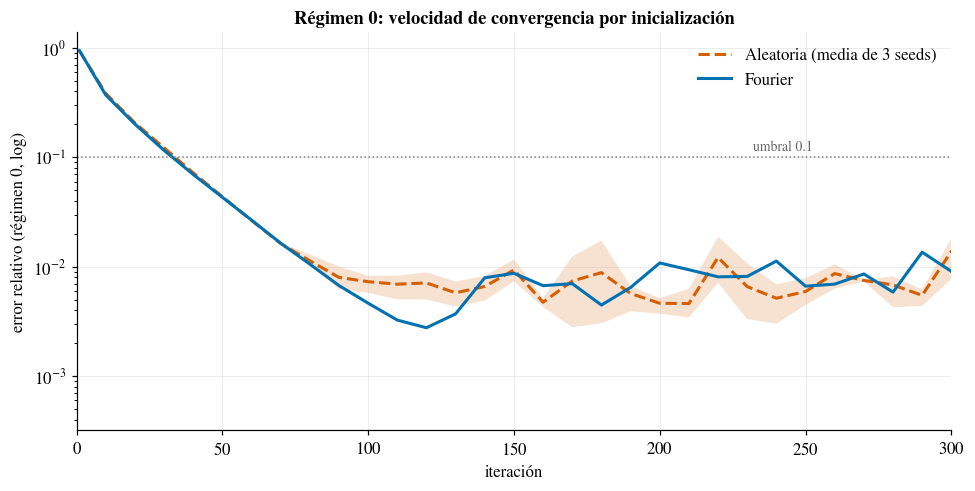

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.6))
# error relativo del régimen 0 (columna 1)
lo0 = reh_r_stack[:, :, 1].min(0); hi0 = reh_r_stack[:, :, 1].max(0)
ax.fill_between(rei_r, lo0, hi0, color=C_RANDOM, alpha=0.18, lw=0)
ax.plot(rei_r, reh_r_stack[:, :, 1].mean(0), color=C_RANDOM, ls=LS_RANDOM, lw=2,
        label="Aleatoria (media de 3 seeds)")
ax.plot(rei_f, reh_f[:, 1], color=C_FOURIER, ls=LS_FOURIER, lw=2, label="Fourier")
ax.axhline(0.1, color="0.5", lw=1, ls=":"); ax.text(232, 0.115, "umbral 0.1", color="0.4", fontsize=9)
ax.set_yscale("log"); ax.set_xlim(0, 300)
ax.set_xlabel("iteración"); ax.set_ylabel("error relativo (régimen 0, log)")
ax.set_title("Régimen 0: velocidad de convergencia por inicialización", fontweight="bold")
ax.legend()
plt.show()


**Hallazgo (honesto).** Con $W_1$ **entrenable**, Fourier y aleatoria convergen
**casi idénticamente**: cruzan el umbral 0.1 con ~1 iteración de diferencia y llegan a
errores finales comparables. Fourier conserva una ventaja pequeña y consistente en el
transitorio temprano, pero no la aceleración dramática que uno esperaría.

¿Por qué? Con 60 características para reconstruir sólo 36 señales, una **proyección
aleatoria de igual escala funciona como un "reservorio"** igual de expresivo; y como
$W_1$ también se entrena, la base aleatoria **aprende** a orientarse hacia una buena
base. La ventaja de arrancar en Fourier queda enmascarada por la propia capacidad de
adaptación de la red.

Esto sugiere la pregunta correcta: **¿la base de Fourier es realmente mejor, o sólo
lo parece?** Lo aislamos en la siguiente sección.

### 4.4 · Prueba de control: **congelar $W_1$** (sólo entrena $W_2$)

¿La base de Fourier es genuinamente "mejor", o basta cualquier base? Lo probamos
**congelando $W_1$** (sólo entrena $W_2$): así la calidad de la reconstrucción depende
sólo de la base de partida, sin que $W_1$ pueda adaptarse.

Con W1 CONGELADA (sólo entrena W2, mismo optimizador Adam):
  Fourier   → error rel. medio 0.003   (pérdida 7.4e-06)
  Aleatoria → error rel. medio 0.009   (pérdida 5.9e-05)
  Fourier logra 7.9× menor pérdida, pero AMBAS reconstruyen a <1 %.


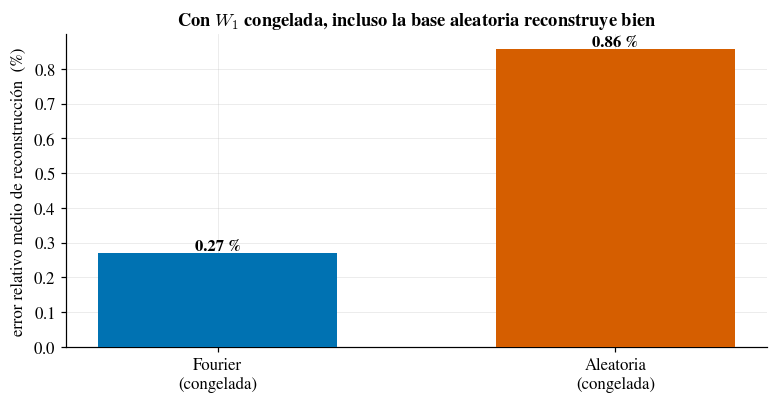

In [ ]:
def loss_frozen(W2, W1, xb):
    return jnp.mean(jnp.sum((jnp.tanh(xb @ W1.T) @ W2.T - xb)**2, axis=1) / xb.shape[1])
vg_frozen = jax.jit(jax.value_and_grad(loss_frozen))

def entrenar_frozen(W1, seed=0, iters=3000, lr=0.02, b1=0.9, b2=0.999, eps=1e-8):
    W2 = 0.05 * jax.random.normal(jax.random.PRNGKey(seed), (N, 2*K))
    m = jnp.zeros_like(W2); v = jnp.zeros_like(W2)
    W1 = jnp.asarray(W1)
    for i in range(1, iters+1):
        L, g = vg_frozen(W2, W1, Xj)
        m = b1*m + (1-b1)*g; v = b2*v + (1-b2)*g**2
        W2 = W2 - lr*(m/(1-b1**i))/(jnp.sqrt(v/(1-b2**i)) + eps)
    xhat = np.asarray(jnp.tanh(Xj @ W1.T) @ W2.T)
    re = np.linalg.norm(xhat - X, axis=1) / np.linalg.norm(X, axis=1)
    return float(L), re

Lf_fz, re_f_fz = entrenar_frozen(W1_fourier)
rand_fz = [entrenar_frozen(init_random(s)["W1"], seed=0) for s in (0, 1, 2)]
Lr_fz = np.mean([r[0] for r in rand_fz]); re_r_fz = np.mean([r[1] for r in rand_fz], axis=0)

print("Con W1 CONGELADA (sólo entrena W2, mismo optimizador Adam):")
print(f"  Fourier   → error rel. medio {re_f_fz.mean():.3f}   (pérdida {Lf_fz:.1e})")
print(f"  Aleatoria → error rel. medio {re_r_fz.mean():.3f}   (pérdida {Lr_fz:.1e})")
print(f"  Fourier logra {Lr_fz/Lf_fz:.1f}× menor pérdida, pero AMBAS reconstruyen a <1 %.")

fig, ax = plt.subplots(figsize=(7.2, 3.8))
labels = ["Fourier\n(congelada)", "Aleatoria\n(congelada)"]
vals = [re_f_fz.mean()*100, re_r_fz.mean()*100]
bars = ax.bar(labels, vals, color=[C_FOURIER, C_RANDOM], width=0.6, zorder=3)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v, f"{v:.2f} %", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("error relativo medio de reconstrucción  (%)")
ax.set_title("Con $W_1$ congelada, incluso la base aleatoria reconstruye bien",
             fontweight="bold")
plt.show()


**Interpretación — efecto reservorio.** Aun *congelada*, una base aleatoria de
igual escala reconstruye las 36 señales con menos del 1 % de error. Con 60
características para sólo 36 señales, la capa de lectura $W_2$ puede **invertir casi
cualquier** proyección de 60 dimensiones (comportamiento de *reservorio*). La base de
Fourier alcanza una pérdida ~8× menor —está mejor condicionada— pero **no** una
reconstrucción prácticamente mejor. Esto explica el empate de la Sección 4: para
*reconstruir*, la identidad de la base importa poco. Su ventaja genuina no está en la
reconstrucción sino en la **compresión**, que aislamos enseguida.

## 5 · Compresión: ¿cuánta señal vive en pocos coeficientes?  *(Rúbrica: 10 pts)*

Usamos los 60 coeficientes de la capa de Fourier, $c=W_1x$. Ordenamos por magnitud,
conservamos los $m$ mayores y reconstruimos por **síntesis** $x\approx\text{BASE}^\top
(c\odot\text{máscara})$. Medimos el error relativo vs. $m$ y contamos cuántos
coeficientes bastan para capturar el **95 % de la energía**.

In [ ]:
def curva_compresion(x):
    c = W1_fourier @ x
    orden = np.argsort(-np.abs(c))
    total = np.sum(x**2)
    errs = np.empty(2*K + 1); eners = np.empty(2*K + 1)
    errs[0] = 1.0; eners[0] = 0.0
    for m in range(1, 2*K + 1):
        mask = np.zeros(2*K); mask[orden[:m]] = 1.0
        xr = BASE.T @ (c * mask)
        errs[m] = np.linalg.norm(xr - x) / np.linalg.norm(x)
        eners[m] = np.sum(xr**2) / total
    return errs, eners

E_err = np.stack([curva_compresion(X[i])[0] for i in range(len(X))])   # (36, 61)
E_ene = np.stack([curva_compresion(X[i])[1] for i in range(len(X))])

def coefs_95(ener):     # primer m con energía >= 0.95
    idx = np.where(ener >= 0.95)[0]; return int(idx[0]) if len(idx) else 2*K
m95 = np.array([coefs_95(E_ene[i]) for i in range(len(X))])
print("Coeficientes necesarios para el 95 % de la energía (mediana por régimen):")
for r in regimenes:
    mr = m95[y==r]
    print(f"  {REG_NOMBRE[r]:32s} mediana {int(np.median(mr)):2d}  (rango {mr.min()}–{mr.max()})")
print(f"  {'GLOBAL':32s} mediana {int(np.median(m95)):2d}")


Coeficientes necesarios para el 95 % de la energía (mediana por régimen):
  Régimen 0 (μ=0, on-grid)         mediana  4  (rango 3–6)
  Régimen 1 (μ=5)                  mediana 10  (rango 7–17)
  Régimen 2 (μ=15, alta frec.)     mediana  7  (rango 4–17)
  GLOBAL                           mediana  7


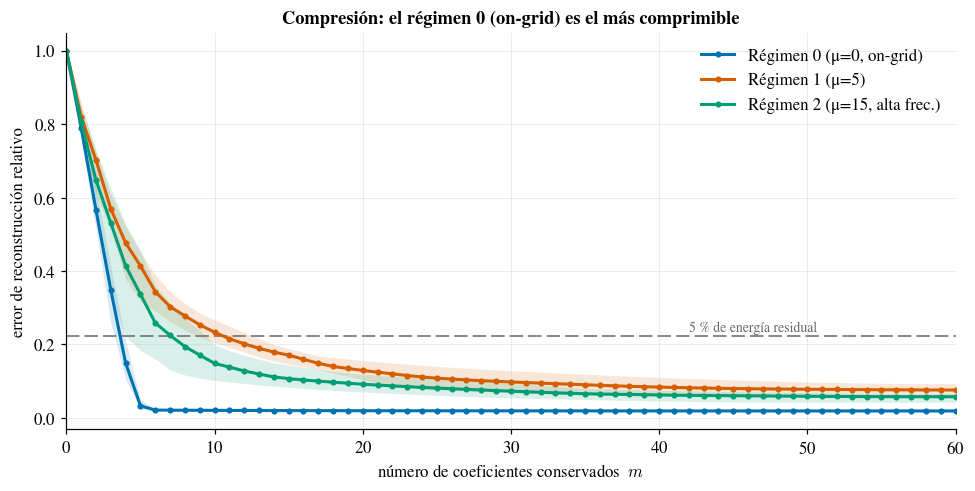

In [ ]:
ms = np.arange(0, 2*K + 1)
fig, ax = plt.subplots(figsize=(9, 4.6))

for r in regimenes:
    med = np.median(E_err[y==r], axis=0)
    lo = np.percentile(E_err[y==r], 25, axis=0); hi = np.percentile(E_err[y==r], 75, axis=0)
    ax.fill_between(ms, lo, hi, color=C_REG[r], alpha=0.15, lw=0)
    ax.plot(ms, med, color=C_REG[r], lw=2, marker="o", ms=3, label=REG_NOMBRE[r])

# Umbral: línea más gruesa y con trazo largo (casi continua)
ax.axhline(np.sqrt(0.05), color="0.45", lw=1.1, ls=(0, (8, 3)), zorder=1)
ax.text(2*K*0.7, np.sqrt(0.05)*1.05, "5 % de energía residual", color="0.4", fontsize=9)

ax.set_xlabel("número de coeficientes conservados  $m$")
ax.set_ylabel("error de reconstrucción relativo")
ax.set_title("Compresión: el régimen 0 (on-grid) es el más comprimible",
             fontweight="bold")
ax.set_xlim(0, 2*K); ax.legend()
plt.show()

**Lectura — aquí sí brilla el régimen 0.** Sus frecuencias enteras caen justo en la
rejilla de Fourier, así que su energía se concentra en **~4 coeficientes** (mediana);
los regímenes 1 y 2, con frecuencias no enteras, sufren **fuga espectral** y necesitan
más coeficientes (mediana 10 y 7). El marcador hueco señala, en cada régimen, el número
mediano de coeficientes para el 95 % de la energía. La ventaja de la base "correcta"
de Fourier se manifiesta con claridad como **compresión**, precisamente en el régimen
donde la base coincide con la física.

## 6 · Conclusiones — ¿ayuda arrancar en la base de Fourier?

**Respuesta corta: en su arranque la capa reproduce *exactamente* la Transformada de
Fourier, pero para reconstruir con $W_1$ entrenable su ventaja de velocidad y calidad es
marginal —una proyección aleatoria de igual escala funciona igual de bien (efecto
reservorio)—. El valor real de la base de Fourier es la *compresión* y la
*interpretabilidad*, y se ve sobre todo en el régimen 0.**

Evidencia reunida:

1. **En su arranque, la capa de Fourier *es* la Transformada de Fourier** — coincide con
   `np.fft` a $10^{-9}$ (Sección 1). Energía media del dataset: **0.756**.

2. **Con $W_1$ entrenable, Fourier ≈ aleatoria** (Sección 4): ambas cruzan el error
   relativo 0.1 con ~1 iteración de diferencia y reconstruyen al ~1 %. Con 60
   características para 36 señales, una proyección aleatoria de igual escala es un
   reservorio igual de capaz, y $W_1$ aprende la buena base sola.

3. **Efecto reservorio** (Sección 4.4): con $W_1$ congelada, incluso una base aleatoria
   de igual escala reconstruye a <1 % —con 60 características para 36 señales, $W_2$
   invierte casi cualquier base—. Fourier logra ~8× menor pérdida (mejor condicionada),
   pero no una reconstrucción prácticamente mejor.

4. **La compresión revela la ventaja física del régimen 0** (Sección 5): sus
   frecuencias enteras caen en la rejilla y bastan **~4 coeficientes** para el 95 % de
   la energía, contra 7–10 en los regímenes dispersivos con fuga espectral.

**Sobre el régimen foco (0):** es el más rápido de reconstruir y, sobre todo, el más
comprimible — justo donde la base de Fourier coincide con la física del medio. Ahí es
donde "arrancar en la base correcta" paga, aunque para la reconstrucción pura el
descenso de gradiente termine igualando a la inicialización aleatoria.
